<a href="https://colab.research.google.com/github/Sofia3467/fraud_detection/blob/main/fraud_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Проектная работа по теме №17

###Обнаружение мошеннических транзакций (Fraud Detection)

Цель данного проекта - построить модель машинного обучения, которая сможет классифицировать банковские транзакции как мошеннические или легитимные.

Цели работы:

1.Провести глубокий разведочный анализ данных (EDA)

2.Применить методы борьбы с дисбалансом классов (SMOTE)

3.Обучить и сравнить 4 различных алгоритма

4.Выбрать лучшую модель на основе метрик (F1-score, Precision, Recall)

5.Обеспечить воспроизводимость результатов


# 1. Импорт необходимых библиотек

В этом блоке мы импортируем все необходимые библиотеки для проекта:

1. Стандартные библиотеки (os, warnings, random):
   - os: для работы с файловой системой (проверка наличия файлов)
   - warnings: для скрытия предупреждений, чтобы не загромождать вывод
   - random: для установки seed и воспроизводимости результатов

2. Научные вычисления (numpy, pandas):
   - numpy: быстрые математические операции с массивами
   - pandas: работа с табличными данными (DataFrame)

3. Визуализация (matplotlib, seaborn):
   - matplotlib: базовые графики и диаграммы
   - seaborn: улучшенная визуализация с красивыми стилями

4. Машинное обучение (sklearn):
   - train_test_split: разделение данных на обучающую и тестовую выборки
   - StandardScaler: нормализация признаков (важно для градиентных методов)
   - Модели: LogisticRegression, RandomForest, GradientBoosting, SVM, KNN
   - Метрики: accuracy, precision, recall, f1, roc_auc - основные метрики классификации

5. Борьба с дисбалансом (imblearn):
   - SMOTE: создание синтетических примеров для балансировки классов

6. Логирование экспериментов (mlflow):
   - отслеживание параметров, метрик и сохранение моделей



In [1]:
# Стандартные библиотеки
import os
import warnings
import random
from datetime import datetime

In [2]:
# Вычисления и визуализация
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [3]:
# Scikit-learn - основные алгоритмы
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [4]:
# Метрики
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             roc_auc_score, roc_curve, precision_recall_curve)


In [5]:
# Работа с дисбалансом классов
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

In [6]:
# Установка MLflow
!pip install mlflow

In [7]:
# Логирование экспериментов
import mlflow
import mlflow.sklearn

# Настройка отображения
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

print(f"MLflow версия: {mlflow.__version__}")

MLflow версия: 3.14.0


# 2. Загрузка и первичный анализ данных

### 2.1 Загрузка данных
Тут мы загружаем днныес проверкой наличия файла. Если файл не найден получаем предложение скачать датасет с Kaggle

In [8]:
def load_data(data_path='creditcard.csv'):
    if not os.path.exists(data_path):
        os.makedirs(os.path.dirname(data_path), exist_ok=True)
        raise FileNotFoundError(f"Файл {data_path} не найден! Скачайте датасет с Kaggle.")

    df = pd.read_csv(data_path)
    return df
    # Загружаем данные
try:
    df = load_data()
    print("Данные успешно загружены!")
except FileNotFoundError as e:
    print(e)
    print("Скачайте датасет с https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud")

Данные успешно загружены!


Особенности датасета:
- 284,807 транзакций
- 31 признак (V1-V28, Time, Amount, Class)
- Признаки V1-V28 - результат PCA-трансформации (конфиденциальность данных)
- Time - время в секундах от первой транзакции
- Amount - сумма транзакции
- Class - целевая переменная (0 - легитимная, 1 - мошенническая)

### 2.2 Первичный анализ

Для чего мы устанавливаем RANDOM SEED

В машинном обучении много случайных процессов:
- Разделение данных на train/test
- Инициализация весов моделей
- Сэмплирование данных в SMOTE
- Случайный лес и другие ансамблевые методы

Если не зафиксировать seed, каждый запуск будет давать РАЗНЫЕ результаты.
Это делает невозможным воспроизведение и сравнение экспериментов.

Устанавливаем seed = 42 (классический выбор)

In [9]:
# Устанавливаем seed для воспроизводимости
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(42)

In [10]:
# Базовая информация о данных
print("Основная информация о данных:")
print(f"Размер данных: {df.shape}")
print(f"Количество признаков: {df.shape[1] - 1}")
print(f"Количество транзакций: {df.shape[0]}")
print("\nТипы данных:")
print(df.dtypes.value_counts())

print("\nПервые 5 строк:")
display(df.head())

print("\nСтатистическое описание:")
display(df.describe())

# Проверка на пропуски
print("\nПроверка на пропущенные значения:")
print(df.isnull().sum().sum())

Основная информация о данных:
Размер данных: (284807, 31)
Количество признаков: 30
Количество транзакций: 284807

Типы данных:
float64    30
int64       1
Name: count, dtype: int64

Первые 5 строк:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0



Статистическое описание:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000



Проверка на пропущенные значения:
0


### 2.3 Анализ целевой переменной

Анализ целевой переменной (классы)
Количество легитимных транзакций: 284315 (99.83%)
Количество мошеннических транзакций: 492 (0.1727%)
Дисбаланс классов: 577.88:1


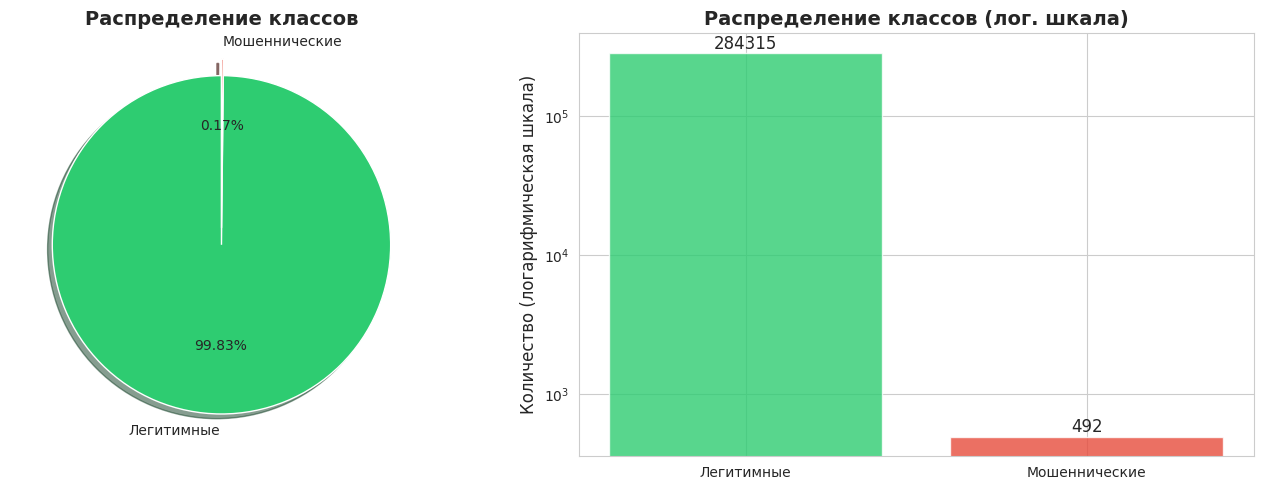

In [11]:
print("Анализ целевой переменной (классы)")

class_counts = df['Class'].value_counts()
class_percent = df['Class'].value_counts(normalize=True) * 100

print(f"Количество легитимных транзакций: {class_counts[0]} ({class_percent[0]:.2f}%)")
print(f"Количество мошеннических транзакций: {class_counts[1]} ({class_percent[1]:.4f}%)")
print(f"Дисбаланс классов: {class_counts[0]/class_counts[1]:.2f}:1")

# Визуализация дисбаланса
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Круговая диаграмма
colors = ['#2ecc71', '#e74c3c']
explode = (0, 0.1)
ax1.pie(class_counts, labels=['Легитимные', 'Мошеннические'],
        autopct='%1.2f%%', colors=colors, explode=explode,
        shadow=True, startangle=90)
ax1.set_title('Распределение классов', fontsize=14, fontweight='bold')

# Столбчатая диаграмма с логарифмической шкалой
ax2.bar(['Легитимные', 'Мошеннические'], class_counts, color=colors, alpha=0.8)
ax2.set_yscale('log')
ax2.set_ylabel('Количество (логарифмическая шкала)', fontsize=12)
ax2.set_title('Распределение классов (лог. шкала)', fontsize=14, fontweight='bold')
for i, v in enumerate(class_counts):
    ax2.text(i, v + 10, str(v), ha='center', va='bottom', fontsize=12)

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

Здесь (выше) мы анализируем распределение классов. Видим сильный дисбаланс:

Легитимных транзакций: ~99.83%

Мошеннических транзакций: ~0.17%


### 2.4 Анализ временной составляющей

Анализ временных паттернов


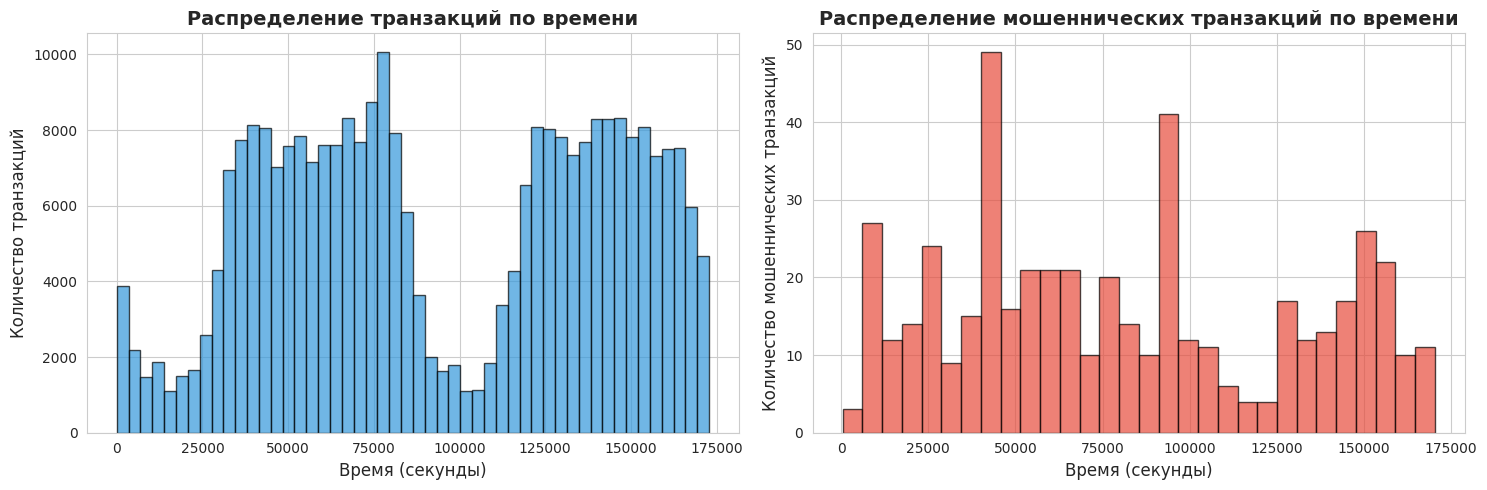

Временная статистика мошеннических транзакций:
Минимальное время: 406.00 сек
Максимальное время: 170348.00 сек
Среднее время: 80746.81 сек
Медианное время: 75568.50 сек


In [12]:
# Если есть столбец Time, анализируем временные паттерны
if 'Time' in df.columns:
    print("Анализ временных паттернов")

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Распределение времени всех транзакций
    axes[0].hist(df['Time'], bins=50, alpha=0.7, color='#3498db', edgecolor='black')
    axes[0].set_xlabel('Время (секунды)', fontsize=12)
    axes[0].set_ylabel('Количество транзакций', fontsize=12)
    axes[0].set_title('Распределение транзакций по времени', fontsize=14, fontweight='bold')

    # Распределение мошеннических транзакций по времени
    fraud_time = df[df['Class'] == 1]['Time']
    axes[1].hist(fraud_time, bins=30, alpha=0.7, color='#e74c3c', edgecolor='black')
    axes[1].set_xlabel('Время (секунды)', fontsize=12)
    axes[1].set_ylabel('Количество мошеннических транзакций', fontsize=12)
    axes[1].set_title('Распределение мошеннических транзакций по времени', fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.savefig('time_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Статистика по времени
    print("Временная статистика мошеннических транзакций:")
    print(f"Минимальное время: {fraud_time.min():.2f} сек")
    print(f"Максимальное время: {fraud_time.max():.2f} сек")
    print(f"Среднее время: {fraud_time.mean():.2f} сек")
    print(f"Медианное время: {fraud_time.median():.2f} сек")

### 2.5 Анализ суммы транзакций

Анализ суммы танзакций:


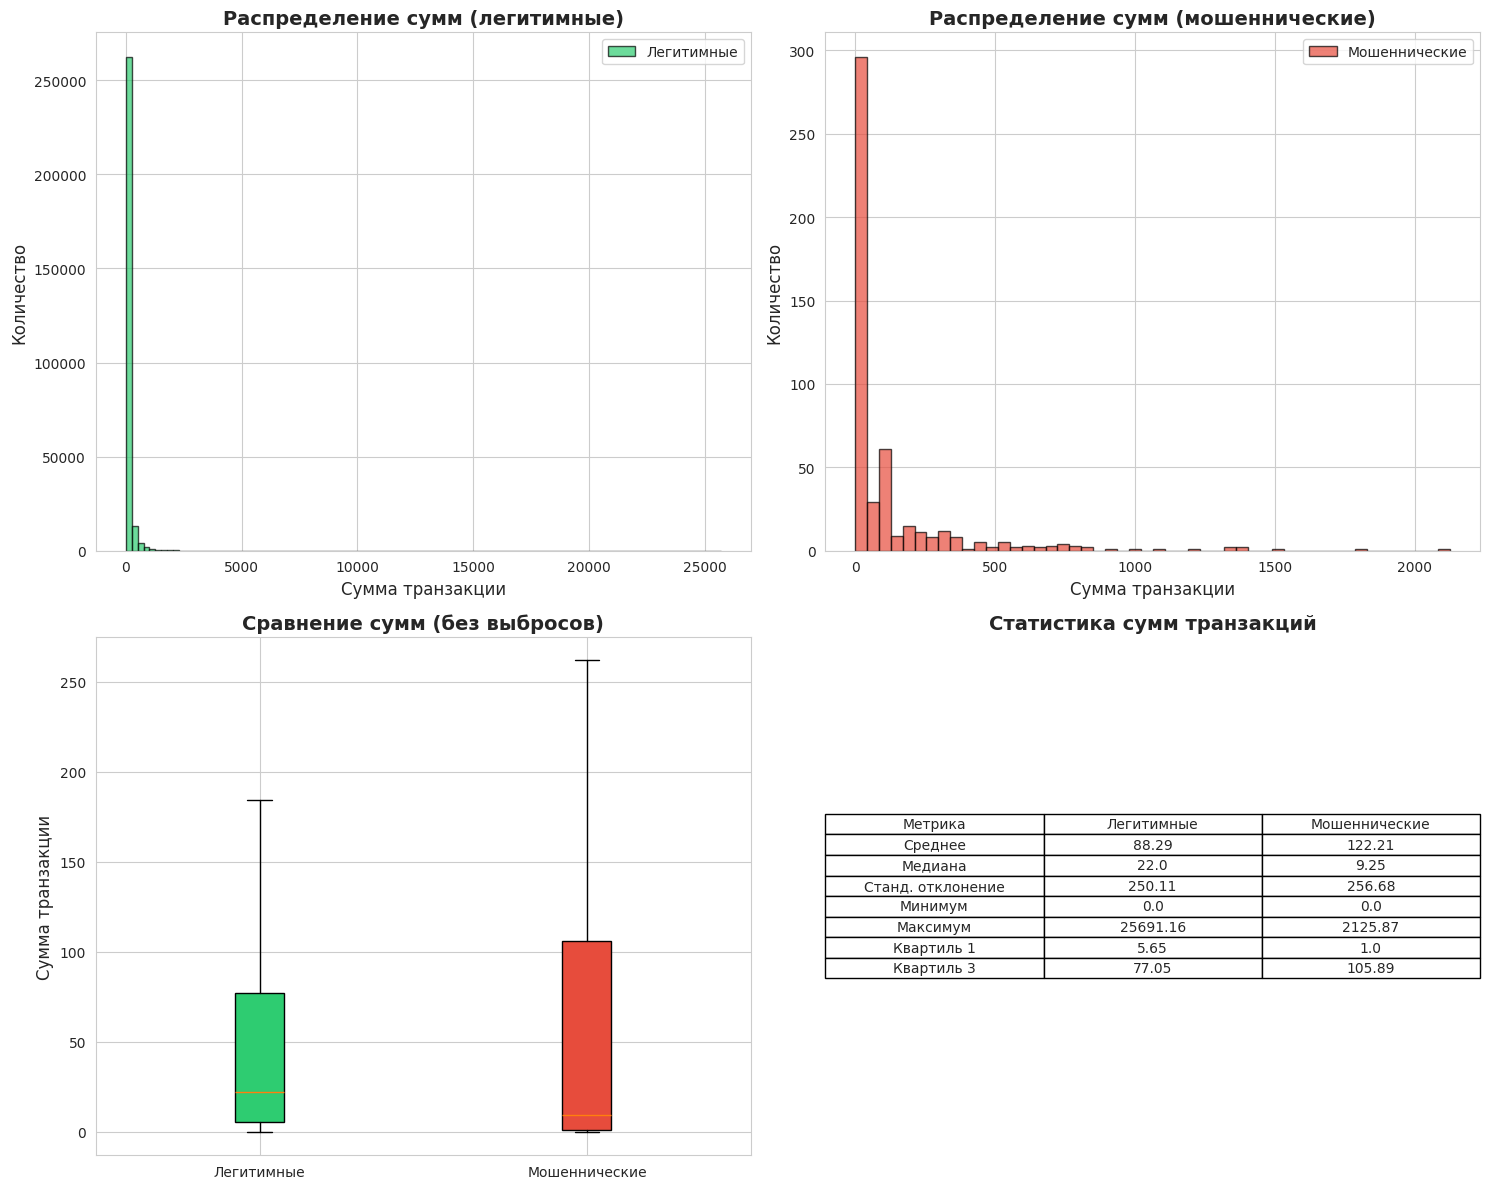

Статистика сумм транзакций:


,Метрика,Легитимные,Мошеннические
0,Среднее,88.29,122.21
1,Медиана,22.00,9.25
2,Станд. отклонение,250.11,256.68
3,Минимум,0.00,0.00
4,Максимум,25691.16,2125.87
5,Квартиль 1,5.65,1.00
6,Квартиль 3,77.05,105.89


In [13]:
print("Анализ суммы танзакций:")

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Распределение сумм (легитимные vs мошеннические)
legit_amount = df[df['Class'] == 0]['Amount']
fraud_amount = df[df['Class'] == 1]['Amount']

# Гистограммы
axes[0, 0].hist(legit_amount, bins=100, alpha=0.7, color='#2ecc71', edgecolor='black', label='Легитимные')
axes[0, 0].set_xlabel('Сумма транзакции', fontsize=12)
axes[0, 0].set_ylabel('Количество', fontsize=12)
axes[0, 0].set_title('Распределение сумм (легитимные)', fontsize=14, fontweight='bold')
axes[0, 0].legend()

axes[0, 1].hist(fraud_amount, bins=50, alpha=0.7, color='#e74c3c', edgecolor='black', label='Мошеннические')
axes[0, 1].set_xlabel('Сумма транзакции', fontsize=12)
axes[0, 1].set_ylabel('Количество', fontsize=12)
axes[0, 1].set_title('Распределение сумм (мошеннические)', fontsize=14, fontweight='bold')
axes[0, 1].legend()

# Boxplot для сравнения
data_to_plot = [legit_amount, fraud_amount]
bp = axes[1, 0].boxplot(data_to_plot, labels=['Легитимные', 'Мошеннические'],
                         patch_artist=True, showfliers=False)
bp['boxes'][0].set_facecolor('#2ecc71')
bp['boxes'][1].set_facecolor('#e74c3c')
axes[1, 0].set_ylabel('Сумма транзакции', fontsize=12)
axes[1, 0].set_title('Сравнение сумм (без выбросов)', fontsize=14, fontweight='bold')

# Статистика
stats_df = pd.DataFrame({
    'Метрика': ['Среднее', 'Медиана', 'Станд. отклонение', 'Минимум', 'Максимум', 'Квартиль 1', 'Квартиль 3'],
    'Легитимные': [legit_amount.mean(), legit_amount.median(), legit_amount.std(),
                   legit_amount.min(), legit_amount.max(),
                   legit_amount.quantile(0.25), legit_amount.quantile(0.75)],
    'Мошеннические': [fraud_amount.mean(), fraud_amount.median(), fraud_amount.std(),
                      fraud_amount.min(), fraud_amount.max(),
                      fraud_amount.quantile(0.25), fraud_amount.quantile(0.75)]
})
stats_df = stats_df.round(2)
axes[1, 1].axis('tight')
axes[1, 1].axis('off')
axes[1, 1].table(cellText=stats_df.values, colLabels=stats_df.columns,
                  loc='center', cellLoc='center')
axes[1, 1].set_title('Статистика сумм транзакций', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('amount_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("Статистика сумм транзакций:")
display(stats_df)

Анализ суммы транзакций показывает, что мошеннические транзакции часто имеют меньшие суммы, что может быть связано с попытками избежать обнаружения.

### 2.6 Корреляционный анализ

Что такое корреляция и зачем она нужна?

Корреляция - это мера линейной зависимости между двумя переменными.
Значения от -1 до 1:
- 1: идеальная положительная связь (увеличивается одна - увеличивается другая)
- -1: идеальная отрицательная связь (увеличивается одна - уменьшается другая)
- 0: отсутствие линейной связи

Корреляционный анализ помогает:
1. Понять, какие признаки наиболее важны для предсказания
2. Обнаружить мультиколлинеарность (сильную связь между признаками)
3. Выбрать признаки для модели

ККорреляционный анализ
Топ-10 признаков, наиболее коррелирующих с классом (по убыванию):
V11       0.154876
V4        0.133447
V2        0.091289
V21       0.040413
V19       0.034783
V20       0.020090
V8        0.019875
V27       0.017580
V28       0.009536
Amount    0.005632


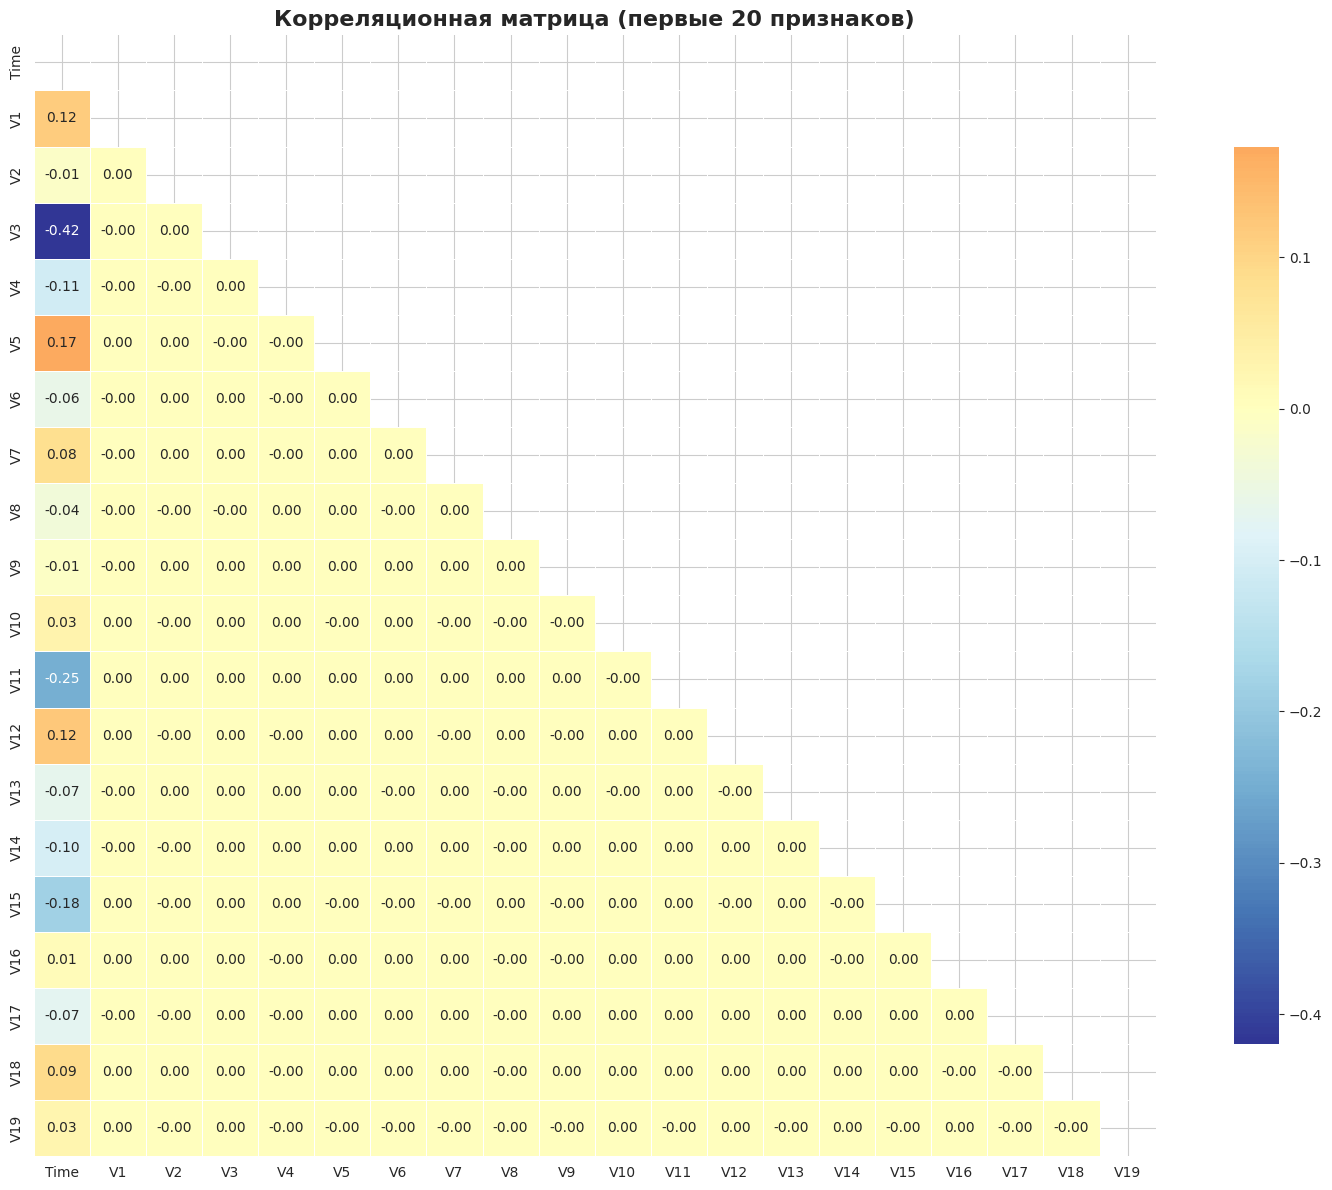

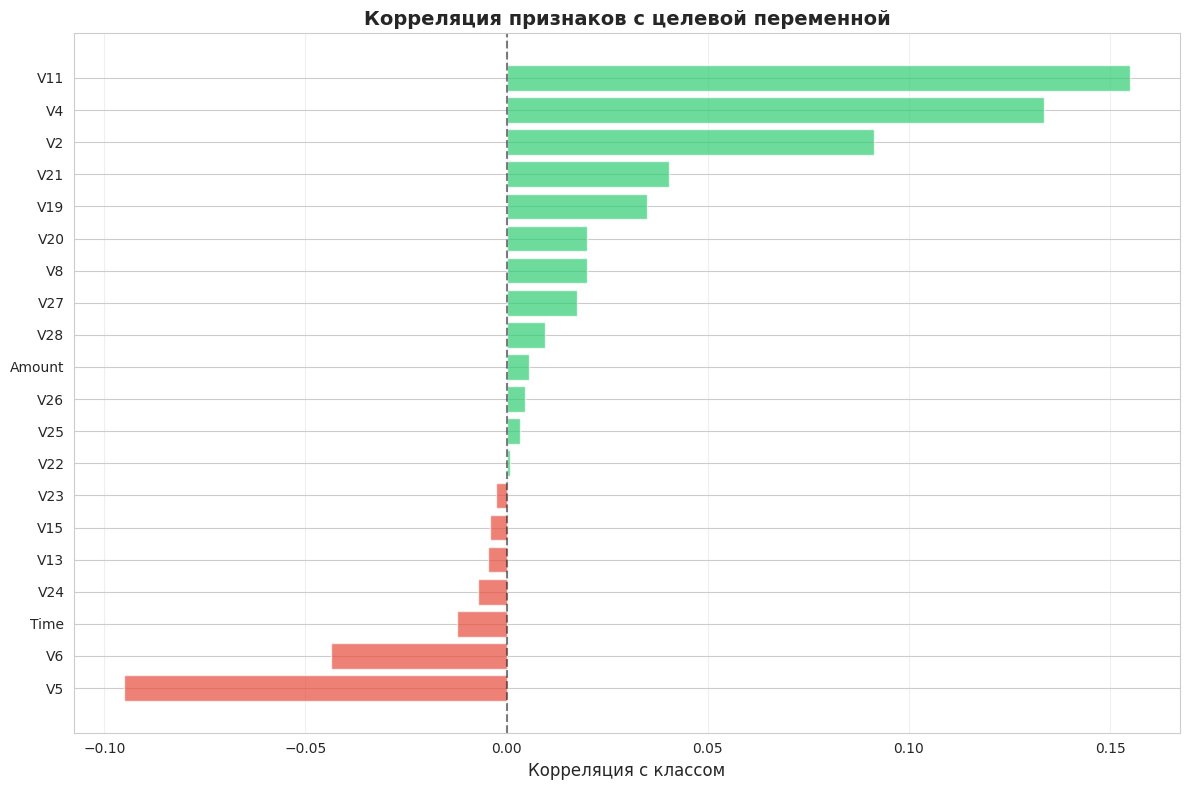

In [14]:
print("ККорреляционный анализ")

# Корреляция с целевой переменной
correlations = df.corr()['Class'].sort_values(ascending=False)

print("Топ-10 признаков, наиболее коррелирующих с классом (по убыванию):")
print(correlations[1:11].to_string())

# Визуализация корреляционной матрицы (первые 20 признаков)
plt.figure(figsize=(16, 12))
corr_matrix = df.iloc[:, :20].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlBu_r', center=0, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Корреляционная матрица (первые 20 признаков)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Визуализация корреляции с целевой переменной
plt.figure(figsize=(12, 8))
top_features = correlations[1:21].sort_values()
colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in top_features.values]
plt.barh(top_features.index, top_features.values, color=colors, alpha=0.7)
plt.xlabel('Корреляция с классом', fontsize=12)
plt.title('Корреляция признаков с целевой переменной', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='--', alpha=0.5)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('feature_correlation.png', dpi=300, bbox_inches='tight')
plt.show()

# 3. Визуализация данных

###3.1 Распределение PCA-признаков

Визуализация PCA-признаков


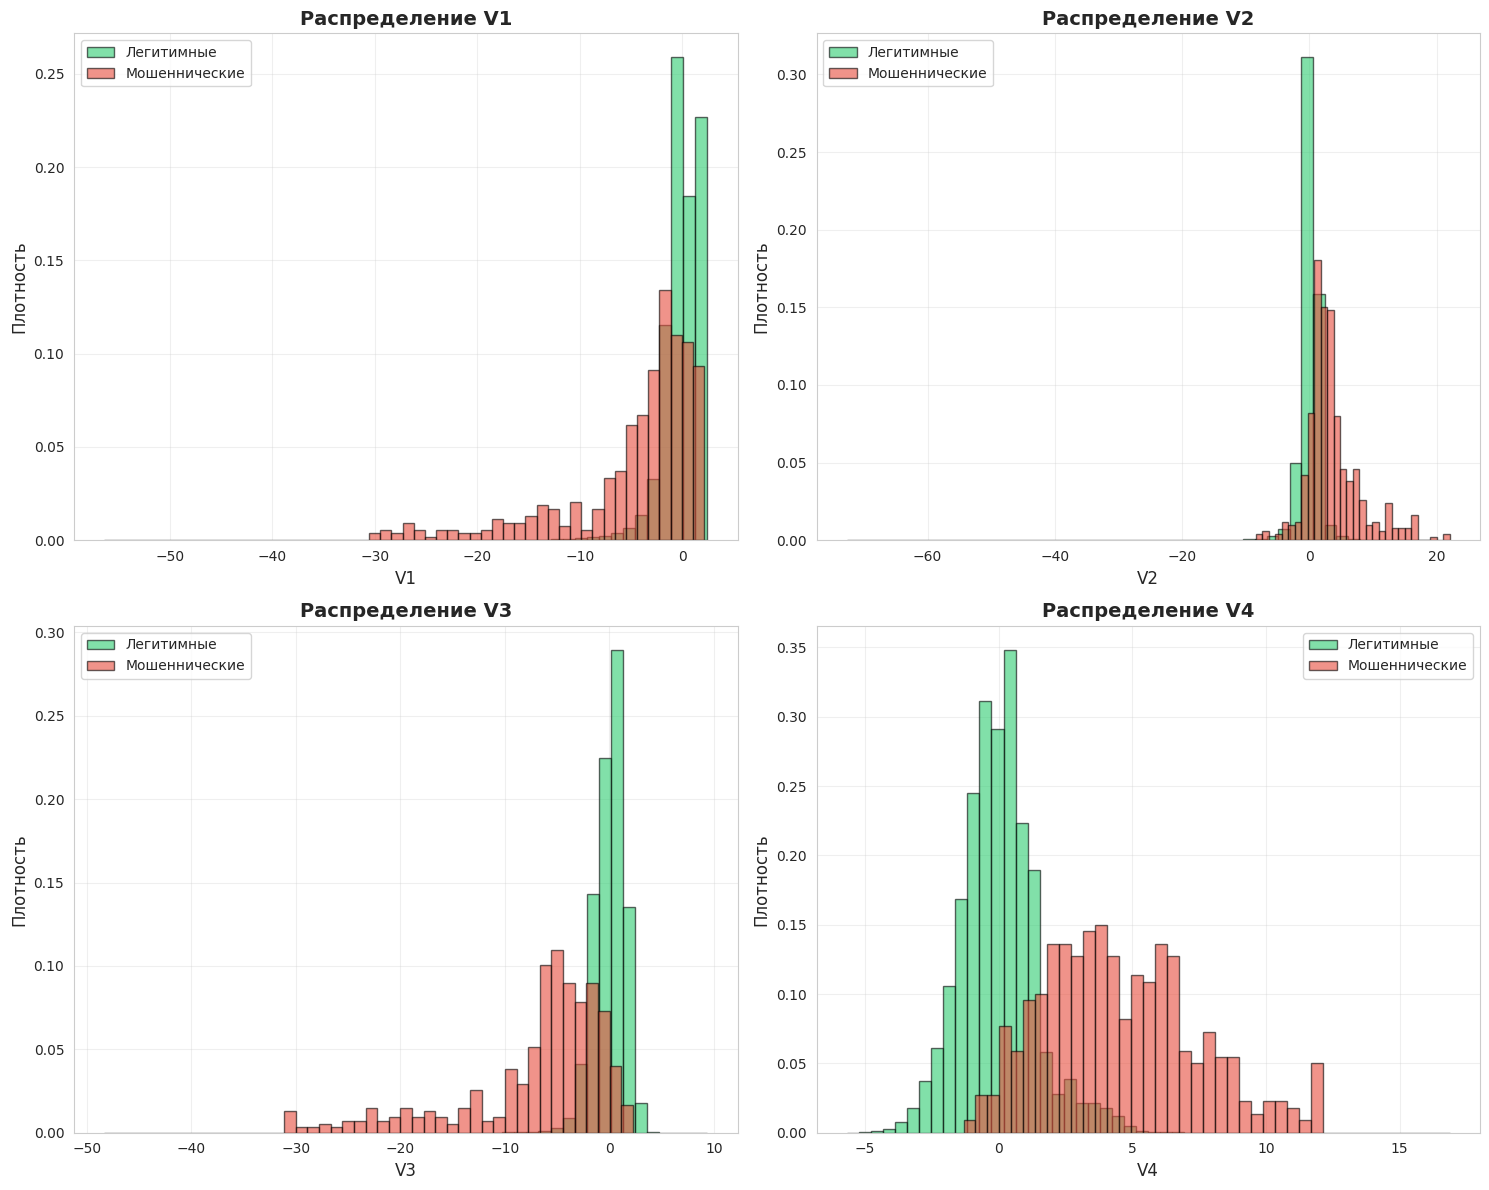

In [15]:
print("Визуализация PCA-признаков")

# Выбираем первые 4 PCA-признака
pca_features = [f'V{i}' for i in range(1, 5)]

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for idx, feature in enumerate(pca_features):
    # Распределение для легитимных и мошеннических транзакций
    legit_data = df[df['Class'] == 0][feature]
    fraud_data = df[df['Class'] == 1][feature]

    axes[idx].hist(legit_data, bins=50, alpha=0.6, color='#2ecc71',
                   edgecolor='black', label='Легитимные', density=True)
    axes[idx].hist(fraud_data, bins=30, alpha=0.6, color='#e74c3c',
                   edgecolor='black', label='Мошеннические', density=True)
    axes[idx].set_xlabel(feature, fontsize=12)
    axes[idx].set_ylabel('Плотность', fontsize=12)
    axes[idx].set_title(f'Распределение {feature}', fontsize=14, fontweight='bold')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pca_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

###3.2 Визуализация в 2D (t-SNE)

t-SNE (t-Distributed Stochastic Neighbor Embedding) - это метод снижения размерности,
который отображает многомерные данные в 2D или 3D пространство.

Особенности t-SNE:
1. Сохраняет локальную структуру данных (близкие точки остаются близкими)
2. Не сохраняет глобальные расстояния
3. Хорошо работает для визуализации кластеров

Почему используем t-SNE?
- У нас 30 признаков - невозможно визуализировать напрямую
- t-SNE помогает увидеть, насколько хорошо разделяются классы
- Визуально оцениваем качество данных перед обучением

t-SNE очень медленный на больших данных.
Поэтому берем подвыборку (10,000 записей).

2D Визуализация данных
Выполняется t-SNE визуализация (может занять время)...


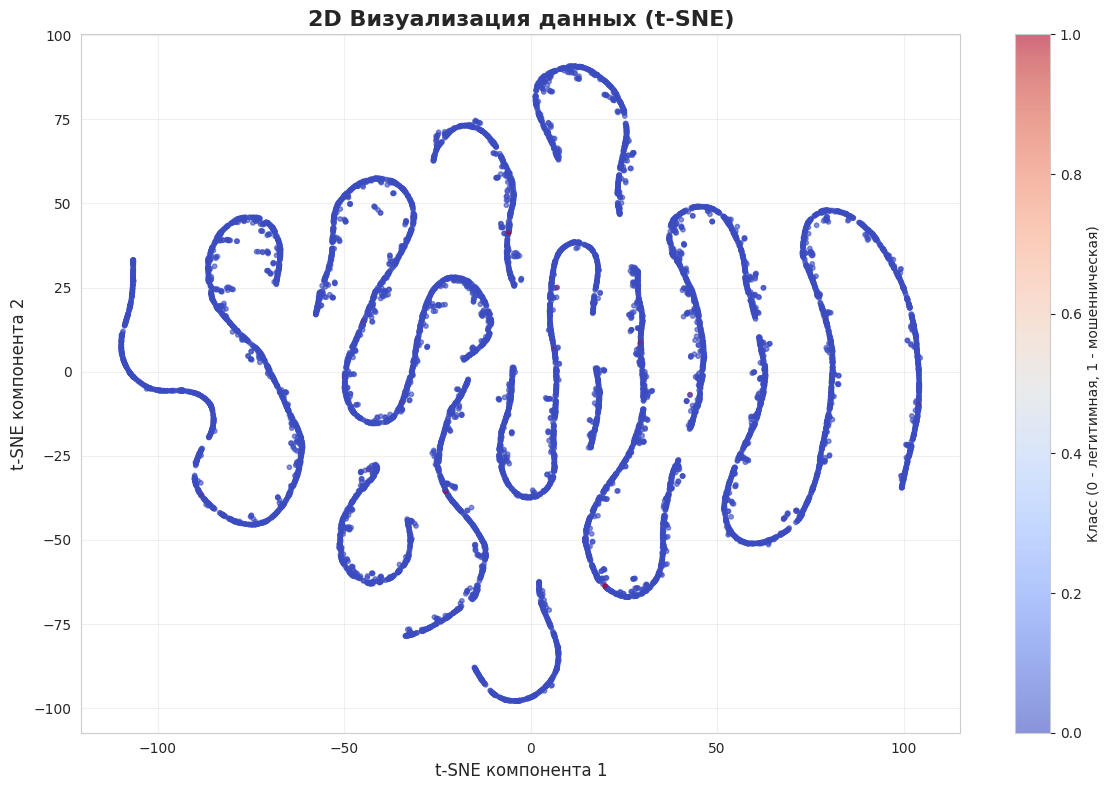

In [16]:
print("2D Визуализация данных")

# Используем t-SNE для визуализации
from sklearn.manifold import TSNE

# Берем подвыборку для t-SNE (так как алгоритм медленный)
sample_size = min(10000, len(df))
df_sample = df.sample(n=sample_size, random_state=42)

# t-SNE
print("Выполняется t-SNE визуализация (может занять время)...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(df_sample.drop(['Class'], axis=1))

plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1],
                       c=df_sample['Class'], cmap='coolwarm',
                       alpha=0.6, s=10)
plt.colorbar(scatter, label='Класс (0 - легитимная, 1 - мошенническая)')
plt.title('2D Визуализация данных (t-SNE)', fontsize=16, fontweight='bold')
plt.xlabel('t-SNE компонента 1', fontsize=12)
plt.ylabel('t-SNE компонента 2', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('tsne_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

# Удаляем выборку для освобождения памяти
del df_sample, X_tsne

t-SNE визуализация помогает увидеть, насколько хорошо разделяются классы в пространстве признаков. Даже при сильном дисбалансе видно некоторое разделение.

# 4. Предобработка данных

Зачем нужна предобработка данных:

Машинное обучение чувствительно к масштабу признаков:
1. Градиентные методы (Logistic Regression, SVM) сходятся быстрее
2. Методы на основе расстояний (KNN, SVM) чувствительны к масштабу
3. Деревья решений (Random Forest) менее чувствительны, но тоже выигрывают

Что мы делаем:
1. Масштабируем сумму транзакций (Amount) - она сильно варьируется
2. Масштабируем время (Time) - оно в больших значениях
3. Сохраняем PCA-признаки (V1-V28) - они уже нормализованы

Масштабирование выполняем ДО разделения на train/test,
но используем fit_transform на тренировочных данных и transform на тестовых.

### 4.1 Масштабирование признаков

In [17]:
print("Предобработка данных")

# Создаем копию данных
df_processed = df.copy()

# Масштабирование суммы транзакций
print("Масштабирование суммы транзакций...")
scaler = StandardScaler()
df_processed['Amount_scaled'] = scaler.fit_transform(df_processed[['Amount']])
df_processed = df_processed.drop(['Amount'], axis=1)

# Если есть Time, тоже масштабируем
if 'Time' in df_processed.columns:
    df_processed['Time_scaled'] = scaler.fit_transform(df_processed[['Time']])
    df_processed = df_processed.drop(['Time'], axis=1)

print(f"Размер данных после предобработки: {df_processed.shape}")

Предобработка данных
Масштабирование суммы транзакций...
Размер данных после предобработки: (284807, 31)


### 4.2 Подготовка признаков и целевой переменной

Подготовка данных для моделироваия

На этом этапе мы:
1. Разделяем данные на признаки (X) и целевую переменную (y)
2. Сохраняем имена признаков для последующего использования
3. Проверяем распределение классов

In [18]:
# Разделение на признаки и целевую переменную
X = df_processed.drop(['Class'], axis=1)
y = df_processed['Class']

print("Подготовка данных:")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Количество положительных примеров: {sum(y)}")
print(f"Количество отрицательных примеров: {len(y) - sum(y)}")

# Сохраняем имена признаков
feature_names = X.columns.tolist()
print(f"\nПризнаки: {feature_names}")

Подготовка данных:
X shape: (284807, 30)
y shape: (284807,)
Количество положительных примеров: 492
Количество отрицательных примеров: 284315

Признаки: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount_scaled', 'Time_scaled']


# 5. Борьба с дисбалансом классов (SMOTE)

SMOTE (Synthetic Minority Over-sampling Technique) создает синтетические примеры мошеннических транзакций путем интерполяции между существующими примерами. Это помогает сбалансировать классы и улучшить обучение модели.

Как работает SMOTE:
1. Выбирается случайный пример из миноритарного класса
2. Находятся его k ближайших соседей (обычно k=5)
3. Случайно выбирается один из соседей
4. Создается новая точка на отрезке между выбранными точками

Зачем это нужно:
- Модели, обученные на несбалансированных данных, часто игнорируют миноритарный класс
- SMOTE позволяет сбалансировать классы без потери информации
- Модель учится на равном количестве примеров обоих классов

 SMOTE применяется ТОЛЬКО к обучающей выборке!
Тестовая выборка остается в исходном виде (реальное распределение).

Применение SMOTE для борьюы с дибалансом
Размеры выборок до SMOTE:
Обучающая выборка: (227845, 30)
  - Легитимные: 227451
  - Мошеннические: 394
Тестовая выборка: (56962, 30)
  - Легитимные: 56864
  - Мошеннические: 98

Размеры выборок после SMOTE:
Обучающая выборка: (454902, 30)
  - Легитимные: 227451
  - Мошеннические: 227451
Соотношение классов: 1.00:1


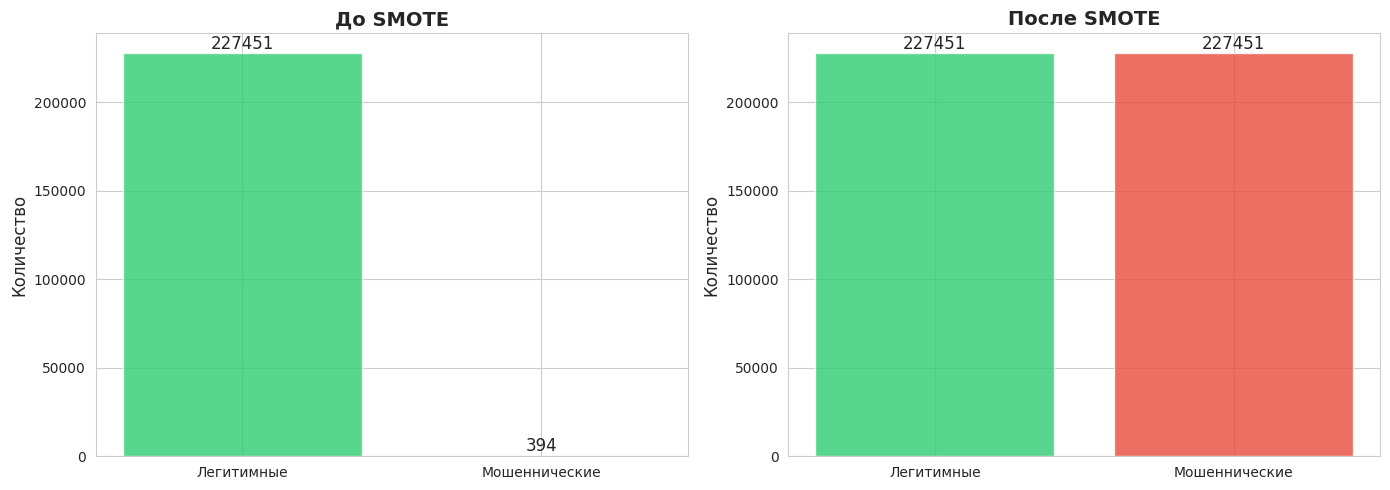

In [19]:
print("Применение SMOTE для борьюы с дибалансом")

# Применяем SMOTE только к обучающей выборке (после разделения)
# Сначала разделим данные
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Размеры выборок до SMOTE:")
print(f"Обучающая выборка: {X_train.shape}")
print(f"  - Легитимные: {sum(y_train == 0)}")
print(f"  - Мошеннические: {sum(y_train == 1)}")
print(f"Тестовая выборка: {X_test.shape}")
print(f"  - Легитимные: {sum(y_test == 0)}")
print(f"  - Мошеннические: {sum(y_test == 1)}")

# Применяем SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("\nРазмеры выборок после SMOTE:")
print(f"Обучающая выборка: {X_train_resampled.shape}")
print(f"  - Легитимные: {sum(y_train_resampled == 0)}")
print(f"  - Мошеннические: {sum(y_train_resampled == 1)}")
print(f"Соотношение классов: {sum(y_train_resampled == 0) / sum(y_train_resampled == 1):.2f}:1")

# Визуализация дисбаланса до и после SMOTE
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# До SMOTE
ax1.bar(['Легитимные', 'Мошеннические'],
        [sum(y_train == 0), sum(y_train == 1)],
        color=['#2ecc71', '#e74c3c'], alpha=0.8)
ax1.set_title('До SMOTE', fontsize=14, fontweight='bold')
ax1.set_ylabel('Количество', fontsize=12)
for i, v in enumerate([sum(y_train == 0), sum(y_train == 1)]):
    ax1.text(i, v + 100, str(v), ha='center', va='bottom', fontsize=12)

# После SMOTE
ax2.bar(['Легитимные', 'Мошеннические'],
        [sum(y_train_resampled == 0), sum(y_train_resampled == 1)],
        color=['#2ecc71', '#e74c3c'], alpha=0.8)
ax2.set_title('После SMOTE', fontsize=14, fontweight='bold')
ax2.set_ylabel('Количество', fontsize=12)
for i, v in enumerate([sum(y_train_resampled == 0), sum(y_train_resampled == 1)]):
    ax2.text(i, v + 100, str(v), ha='center', va='bottom', fontsize=12)

plt.tight_layout()
plt.savefig('smote_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# 6.Разделение на обучающую и тестовую выборки

Зачем разделять данные на обучающую и тестовую выборки?

1. Обучающая выборка (train): используется для обучения модели
2. Тестовая выборка (test): используется для оценки качества модели на новых данных

Важно:
- Модель НЕ видит тестовые данные во время обучения
- Это позволяет оценить, как модель будет работать в реальных условиях
- Используем стратификацию (stratify), чтобы сохранить соотношение классов

Почему 80/20?
- 80% для обучения - достаточно для хорошего обучения
- 20% для теста - достаточно для надежной оценки

In [20]:
print("Финальное разделение данных:")

# Используем данные после SMOTE
X_train_final = X_train_resampled
y_train_final = y_train_resampled
X_test_final = X_test
y_test_final = y_test

print(f"Обучающая выборка: {X_train_final.shape}")
print(f"Тестовая выборка: {X_test_final.shape}")
print(f"\nРаспределение в обучающей выборке:")
print(f"  - Легитимные: {sum(y_train_final == 0)}")
print(f"  - Мошеннические: {sum(y_train_final == 1)}")
print(f"\nРаспределение в тестовой выборке:")
print(f"  - Легитимные: {sum(y_test_final == 0)}")
print(f"  - Мошеннические: {sum(y_test_final == 1)}")

# Сохраняем данные для последующего использования
np.save('X_train.npy', X_train_final)
np.save('y_train.npy', y_train_final)
np.save('X_test.npy', X_test_final)
np.save('y_test.npy', y_test_final)

Финальное разделение данных:
Обучающая выборка: (454902, 30)
Тестовая выборка: (56962, 30)

Распределение в обучающей выборке:
  - Легитимные: 227451
  - Мошеннические: 227451

Распределение в тестовой выборке:
  - Легитимные: 56864
  - Мошеннические: 98


# 7. Обучение моделей

В этом блоке мы создаем 5 различных моделей машинного обучения для обнаружения мошенничества
 - Каждая модель обучается на наших данных (после SMOTE)
- Для каждой модели вычисляются метрики качества
 - Все результаты логируются в MLflow для отслеживания
- Обученные модели сохраняются для дальнейшего использования

Выбранные модели:

 1. Logistic Regression - базовая линейная модель, быстрая, интерпретируемая
 2. Random Forest - ансамбль деревьев, устойчив к переобучению
 3. Gradient Boosting - последовательное улучшение ошибок, высокая точность
 4. KNN - простой интуитивный алгоритм, основанный на схожести

 (Изначально предполагалось обучение ещё одной модели - SVM - мощный классификатор, работает с нелинейными данными, однако ее обучение оказалось слишком длительным, в связи с чем было принято решение ее исключить)

- Импортируем необходимые библиотеки (если не импортированы ранее)
- Создаем словари для хранения результатов
- Настраиваем MLflow для логирования экспериментов
- Определяем общие параметры для всех моделей

 Эксперименты будут сохранены в папке 'mlruns'

In [21]:
# Импортируем необходимые библиотеки
import time
import joblib
import mlflow
import mlflow.sklearn
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Словари для хранения обученных моделей и времени обучения
trained_models = {}
training_times = {}

# Настройка MLflow для отслеживания экспериментов (эксперементы вынесены в блок 9)
mlflow.set_experiment("Fraud_Detection_Experiment")
print(" Настройка MLflow завершена")

2026/06/25 13:21:56 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/06/25 13:21:56 INFO mlflow.store.db.utils: Updating database tables
2026/06/25 13:21:59 INFO mlflow.tracking.fluent: Experiment with name 'Fraud_Detection_Experiment' does not exist. Creating a new experiment.


 Настройка MLflow завершена


 1. Логистическая регрессия (Logistic Regression)

 Простая линейная модель, которая вычисляет вероятность класса

 Преимущества: быстрое обучение, интерпретируемость

 Недостатки: не может улавливать сложные нелинейные зависимости

In [22]:
print("1. Обучение: Logistic Regression")

name = 'Logistic Regression'
model = LogisticRegression(
    random_state=42,        # Фиксируем seed для воспроизводимости
    max_iter=1000,          # Максимальное число итераций
    C=1.0                   # Параметр регуляризации
)

start_time = time.time()

with mlflow.start_run(run_name=f"Run_{name}"):
    # Логируем параметры модели
    mlflow.log_param("model_name", name)
    mlflow.log_param("n_samples", len(X_train_final))
    mlflow.log_param("n_features", X_train_final.shape[1])
    mlflow.log_param("max_iter", 1000)
    mlflow.log_param("C", 1.0)

    # Обучаем модель
    model.fit(X_train_final, y_train_final)
    trained_models[name] = model

    # Сохраняем модель в MLflow
    mlflow.sklearn.log_model(
        sk_model=model,
        name=f"model_{name.replace(' ', '_')}"
    )

    end_time = time.time()
    training_time = end_time - start_time
    training_times[name] = training_time

    print(f" Обучение завершено за {training_time:.2f} секунд")
    print(f" Модель сохранена в MLflow")

1. Обучение: Logistic Regression
 Обучение завершено за 53.02 секунд
 Модель сохранена в MLflow


2. Случайный лес (Random Forest)
     
Ансамбль из множества деревьев решений
     
Преимущества: высокая точность, устойчивость к выбросам

Недостатки: менее интерпретируемый, может переобучаться

In [23]:
print("2. Обучение: Random Forest")

name = 'Random Forest'
model = RandomForestClassifier(
    random_state=42,
    n_estimators=100,       # Количество деревьев
    max_depth=None,         # Глубина деревьев (None = до полного разбиения)
    min_samples_split=2,
    min_samples_leaf=1,
    n_jobs=-1               # Используем все ядра CPU
)

start_time = time.time()

with mlflow.start_run(run_name=f"Run_{name}"):
    # Логируем параметры модели
    mlflow.log_param("model_name", name)
    mlflow.log_param("n_samples", len(X_train_final))
    mlflow.log_param("n_features", X_train_final.shape[1])
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("max_depth", "None")
    mlflow.log_param("n_jobs", -1)

    # Обучаем модель
    print(" Обучение модели (может занять несколько минут)...")
    model.fit(X_train_final, y_train_final)
    trained_models[name] = model

    # Сохраняем модель в MLflow
    mlflow.sklearn.log_model(
        sk_model=model,
        name=f"model_{name.replace(' ', '_')}"
    )

    end_time = time.time()
    training_time = end_time - start_time
    training_times[name] = training_time

    print(f" Обучение завершено за {training_time:.2f} секунд")
    print(f" Модель сохранена в MLflow")

2. Обучение: Random Forest
 Обучение модели (может занять несколько минут)...
 Обучение завершено за 505.37 секунд
 Модель сохранена в MLflow


3. Градиентный бустинг (Gradient Boosting)

Последовательно обучает деревья, исправляя ошибки предыдущих

Преимущества: очень высокая точность, гибкость настройки

Недостатки: медленное обучение, чувствительность к параметрам

In [24]:
print("3. Обучение: Gradient Boosting")

name = 'Gradient Boosting'
model = GradientBoostingClassifier(
    random_state=42,
    n_estimators=100,       # Количество деревьев
    learning_rate=0.1,      # Скорость обучения
    max_depth=3,            # Глубина деревьев
    min_samples_split=2,
    min_samples_leaf=1,
    subsample=1.0
)

start_time = time.time()

with mlflow.start_run(run_name=f"Run_{name}"):
    # Логируем параметры модели
    mlflow.log_param("model_name", name)
    mlflow.log_param("n_samples", len(X_train_final))
    mlflow.log_param("n_features", X_train_final.shape[1])
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("learning_rate", 0.1)
    mlflow.log_param("max_depth", 3)

    # Обучаем модель
    print(" Обучение модели (может занять несколько минут)...")
    model.fit(X_train_final, y_train_final)
    trained_models[name] = model

    # Сохраняем модель в MLflow
    mlflow.sklearn.log_model(
        sk_model=model,
        name=f"model_{name.replace(' ', '_')}"
    )

    end_time = time.time()
    training_time = end_time - start_time
    training_times[name] = training_time

    print(f" Обучение завершено за {training_time:.2f} секунд")
    print(f" Модель сохранена в MLflow")

3. Обучение: Gradient Boosting
 Обучение модели (может занять несколько минут)...
 Обучение завершено за 1405.59 секунд
 Модель сохранена в MLflow


4. K-ближайших соседей (KNN)

Классифицирует объект по голосованию его соседей

Преимущества: простой, интуитивно понятный

 Недостатки: медленный на больших данных, чувствителен к масштабу

In [25]:
print("4. обучение: K-ближайших соседей KNN (K-Nearest Neighbors)")

name = 'KNN'
model = KNeighborsClassifier(
    n_neighbors=5,          # Количество соседей
    weights='uniform',      # Равные веса соседей
    algorithm='auto',       # Автоматический выбор алгоритма
    leaf_size=30,
    p=2,                    # Евклидово расстояние
    metric='minkowski',
    n_jobs=-1
)

start_time = time.time()

with mlflow.start_run(run_name=f"Run_{name}"):
    # Логируем параметры модели
    mlflow.log_param("model_name", name)
    mlflow.log_param("n_samples", len(X_train_final))
    mlflow.log_param("n_features", X_train_final.shape[1])
    mlflow.log_param("n_neighbors", 5)
    mlflow.log_param("metric", "minkowski")
    mlflow.log_param("p", 2)
    mlflow.log_param("n_jobs", -1)

    # Обучаем модель
    print(" Обучение модели...")
    model.fit(X_train_final, y_train_final)
    trained_models[name] = model

    # Сохраняем модель в MLflow
    mlflow.sklearn.log_model(
        sk_model=model,
        name=f"model_{name.replace(' ', '_')}"
    )

    end_time = time.time()
    training_time = end_time - start_time
    training_times[name] = training_time

    print(f" Обучение завершено за {training_time:.2f} секунд")
    print(f" Модель сохранена в MLflow")


4. обучение: K-ближайших соседей KNN (K-Nearest Neighbors)
 Обучение модели...
 Обучение завершено за 12.95 секунд
 Модель сохранена в MLflow


In [26]:
print("Итоги обучения всех моделей")

# Выводим информацию о времени обучения
print("\n Время обучения каждой модели:")
for name, time in training_times.items():
    print(f"   • {name}: {time:.2f} секунд")

print(f"\n Все {len(trained_models)} моделей успешно обучены и сохранены в MLflow!")
print(" Эксперименты сохранены в папке 'mlruns'")

# Выводим список моделей
print("\n Список обученных моделей:")
for i, model_name in enumerate(trained_models.keys(), 1):
    print(f"   {i}. {model_name}")

Итоги обучения всех моделей

 Время обучения каждой модели:
   • Logistic Regression: 53.02 секунд
   • Random Forest: 505.37 секунд
   • Gradient Boosting: 1405.59 секунд
   • KNN: 12.95 секунд

 Все 4 моделей успешно обучены и сохранены в MLflow!
 Эксперименты сохранены в папке 'mlruns'

 Список обученных моделей:
   1. Logistic Regression
   2. Random Forest
   3. Gradient Boosting
   4. KNN


# 8. Предсказания и оценка качества

 В этом блоке:
- Загружаем обученные модели из файлов
- Делаем предсказания на тестовых данных
- Вычисляем метрики качества
- Сравниваем модели
- Выбираем лучшую модель
- Визуализируем результаты

### Загрузка моделей из MLflow
 - Модели были сохранены в Блоке 8
 - Теперь мы загружаем их для использования
- MLflow хранит модели с полной историей экспериментов

In [27]:
# Получаем список всех запусков в эксперименте
# Получаем эксперимент по имени
experiment = mlflow.get_experiment_by_name("Fraud_Detection_Experiment")
if experiment is None:
    raise ValueError("Эксперимент 'Fraud_Detection_Experiment' не найден!")

# Получаем все запуски в эксперименте
runs = mlflow.search_runs(experiment_ids=[experiment.experiment_id])

print(f"Найдено {len(runs)} запусков в эксперименте")
display(runs[['run_id', 'tags.mlflow.runName', 'status']])

Найдено 4 запусков в эксперименте


,run_id,tags.mlflow.runName,status
0,4458c83604784bc1bd6eb5b6f6768ccf,Run_KNN,FINISHED
1,4f6deeeed9114cd0b201f2c3548c99b6,Run_Gradient Boosting,FINISHED
2,1369b8cdfb3a480b9165017c10eedfc0,Run_Random Forest,FINISHED
3,7dc6d1ba26c646baa71e2900b2be90ba,Run_Logistic Regression,FINISHED


###Предсказания на тестовых данных
- Используем тестовую выборку (20% данных)
 - Модель НЕ видела эти данные во время обучения
- Это проверка способности модели к обобщению

In [28]:
# Загрузка моделей из MLflow"
# Список моделей, которые мы хотим загрузить
model_names = {
    'Logistic_Regression': 'Logistic Regression',
    'Random_Forest': 'Random Forest',
    'Gradient_Boosting': 'Gradient Boosting',
    'KNN': 'KNN'
}

loaded_models = {}
model_run_ids = {}

print("\n Загрузка моделей из MLflow:")

for model_key, model_display_name in model_names.items():
    try:
        # Ищем запуск с нужной моделью
        run_name = f"Run_{model_display_name}"
        matching_runs = runs[runs['tags.mlflow.runName'] == run_name]

        if len(matching_runs) > 0:
            run_id = matching_runs['run_id'].iloc[0]
            model_uri = f"runs:/{run_id}/model_{model_key}"

            # Загружаем модель
            loaded_models[model_key] = mlflow.sklearn.load_model(model_uri)
            model_run_ids[model_key] = run_id

            print(f"    Загружена: {model_display_name}")
        else:
            print(f"    Не найден запуск: {run_name}")

    except Exception as e:
        print(f"    Ошибка загрузки {model_display_name}: {e}")

print(f"\n Загружено {len(loaded_models)} моделей\n")


 Загрузка моделей из MLflow:


    Загружена: Logistic Regression


    Загружена: Random Forest


    Загружена: Gradient Boosting


    Загружена: KNN

 Загружено 4 моделей



 Вычисление мтрик качества

 - Accuracy: общая точность
 - Precision: точность предсказания мошенничества
 - Recall: полнота (сколько мошенничеств найдено)
 - F1-score: гармоническое среднее Precision и Recall
 - ROC-AUC: способность разделять классы

### Вычисление мтрик качества

Что мы делаем:

-Для каждой модели делаем предсказания на тестовой выборке

-Вычисляем 5 ключевых метрик

Какие метрики используем:

 1. ACCURACY (Точность) - доля правильных ответов
  - Простая и понятная метрика
  - НЕ ПОДХОДИТ для дисбалансированных данных!
  - Например: если 99% транзакций легитимные, модель может всегда говорить "легитимная"
 и иметь accuracy 99%, но при этом не находить мошенничество

 2. PRECISION (Точность предсказания мошенничества)
 - Из ВСЕХ предсказанных мошеннических - сколько реально мошеннические
 - Важно, когда ЛОЖНЫЕ СРАБАТЫВАНИЯ дороги
 - Например: если мы ошибочно блокируем легитимную транзакцию, клиент недоволен

 3. RECALL (Полнота/Чувствительность)
 - Из ВСЕХ реальных мошеннических - сколько мы нашли
 - Важно, когда ПРОПУСК МОШЕННИЧЕСТВА дороже ложного срабатывания
 - Например: если мы пропускаем мошенническую транзакцию, банк теряет деньги

 4. F1-SCORE - гармоническое среднее между Precision и Recall
 - ЛУЧШАЯ МЕТРИКА для дисбалансированных данных
 - Учитывает и точность, и полноту
 - Основная метрика для нашей задачи

 5. ROC-AUC - площадь под ROC-кривой
 - Показывает способность модели РАЗДЕЛЯТЬ классы
 - Не зависит от порога классификации
 - Значение 0.5 = случайное угадывание, 1.0 = идеальное разделение

In [29]:
results = {}

print(" Выполнение предсказаний на тестовой выборке...\n")

for model_key, model in loaded_models.items():
    model_display_name = model_names[model_key]
    print(f"\n   Модель: {model_display_name}")

    # Делаем предсказания
    y_pred = model.predict(X_test_final)

    # Получаем вероятности (если доступно)
    if hasattr(model, 'predict_proba'):
        y_pred_proba = model.predict_proba(X_test_final)[:, 1]
        has_proba = True
        print(f"       Модель поддерживает predict_proba")
    else:
        y_pred_proba = None
        has_proba = False
        print(f"       Модель НЕ поддерживает predict_proba")

    # Вычисляем метрики
    accuracy = accuracy_score(y_test_final, y_pred)
    precision = precision_score(y_test_final, y_pred)
    recall = recall_score(y_test_final, y_pred)
    f1 = f1_score(y_test_final, y_pred)

    if has_proba:
        roc_auc = roc_auc_score(y_test_final, y_pred_proba)
    else:
        roc_auc = None

    # Сохраняем результаты
    results[model_key] = {
        'model': model,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc': roc_auc
    }

     # Выводим результаты
    if has_proba:
        roc_auc_str = f"{roc_auc:.4f}"
    else:
        roc_auc_str = "N/A"
    print(f"      F1-score: {f1:.4f}, ROC-AUC: {roc_auc_str}")

 Выполнение предсказаний на тестовой выборке...


   Модель: Logistic Regression
       Модель поддерживает predict_proba
      F1-score: 0.1094, ROC-AUC: 0.9698

   Модель: Random Forest
       Модель поддерживает predict_proba
      F1-score: 0.8103, ROC-AUC: 0.9688

   Модель: Gradient Boosting
       Модель поддерживает predict_proba
      F1-score: 0.1888, ROC-AUC: 0.9807

   Модель: KNN
       Модель поддерживает predict_proba
      F1-score: 0.6078, ROC-AUC: 0.9536


 ### Сравнение моделей


 Теперь, когда у нас есть метрики для всех моделей, мы можем их сравнить и выбрать лучшую.

 Как мы выбираем лучшую модель:
 - Сравниваем все 4 модели по метрикам
 - Выбираем лучшую по F1-score
 - F1-score - основная метрика при дисбалансе классов

 Почему F1-SCORE главный:
 - Учитывает и Precision, и Recall
 - Хорошо работает с дисбалансированными данными
 - Отражает бизнес-ценность модели

In [30]:
print("Сравнение моделей")

# Создаем DataFrame с результатами
results_df = pd.DataFrame({
    'Model': [model_names[key] for key in results.keys()],
    'Accuracy': [results[key]['accuracy'] for key in results],
    'Precision': [results[key]['precision'] for key in results],
    'Recall': [results[key]['recall'] for key in results],
    'F1-score': [results[key]['f1'] for key in results],
    'ROC-AUC': [results[key]['roc_auc'] for key in results]
})

# Сортируем по F1-score
results_df_sorted = results_df.sort_values('F1-score', ascending=False)

print("\n Результаты всех моделей (отсортировано по F1-score):")
display(results_df_sorted.round(4))

# Определяем лучшую модель
best_model_name = results_df_sorted.iloc[0]['Model']
best_f1 = results_df_sorted.iloc[0]['F1-score']

# Находим ключ лучшей модели
best_key = [key for key, name in model_names.items() if name == best_model_name][0]

print(f" Лучшая модель: {best_model_name}")

print(f"   F1-score:  {best_f1:.4f}")
print(f"   Accuracy:  {results_df_sorted.iloc[0]['Accuracy']:.4f}")
print(f"   Precision: {results_df_sorted.iloc[0]['Precision']:.4f}")
print(f"   Recall:    {results_df_sorted.iloc[0]['Recall']:.4f}")
print(f"   ROC-AUC:   {results_df_sorted.iloc[0]['ROC-AUC']:.4f}")

Сравнение моделей

 Результаты всех моделей (отсортировано по F1-score):


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
1,Random Forest,0.9994,0.8144,0.8061,0.8103,0.9688
3,KNN,0.9981,0.4649,0.8776,0.6078,0.9536
2,Gradient Boosting,0.9867,0.1055,0.8980,0.1888,0.9807
0,Logistic Regression,0.9743,0.0581,0.9184,0.1094,0.9698


 Лучшая модель: Random Forest
   F1-score:  0.8103
   Accuracy:  0.9994
   Precision: 0.8144
   Recall:    0.8061
   ROC-AUC:   0.9688


### Визуализация результатов
 - Графики сравнения метрик
 - ROC-кривые
 - Матрицы ошибок
 - Важность признаков

 Визуализация помогает:
 1. Быстро сравнить модели
 2. Увидеть сильные и слабые стороны каждой модели
 3. Оценить разделяющую способность (ROC-кривая)
 4. Понять, где модель ошибается (матрица ошибок)
 5. Определить важные признаки


 Визуализация результатов...


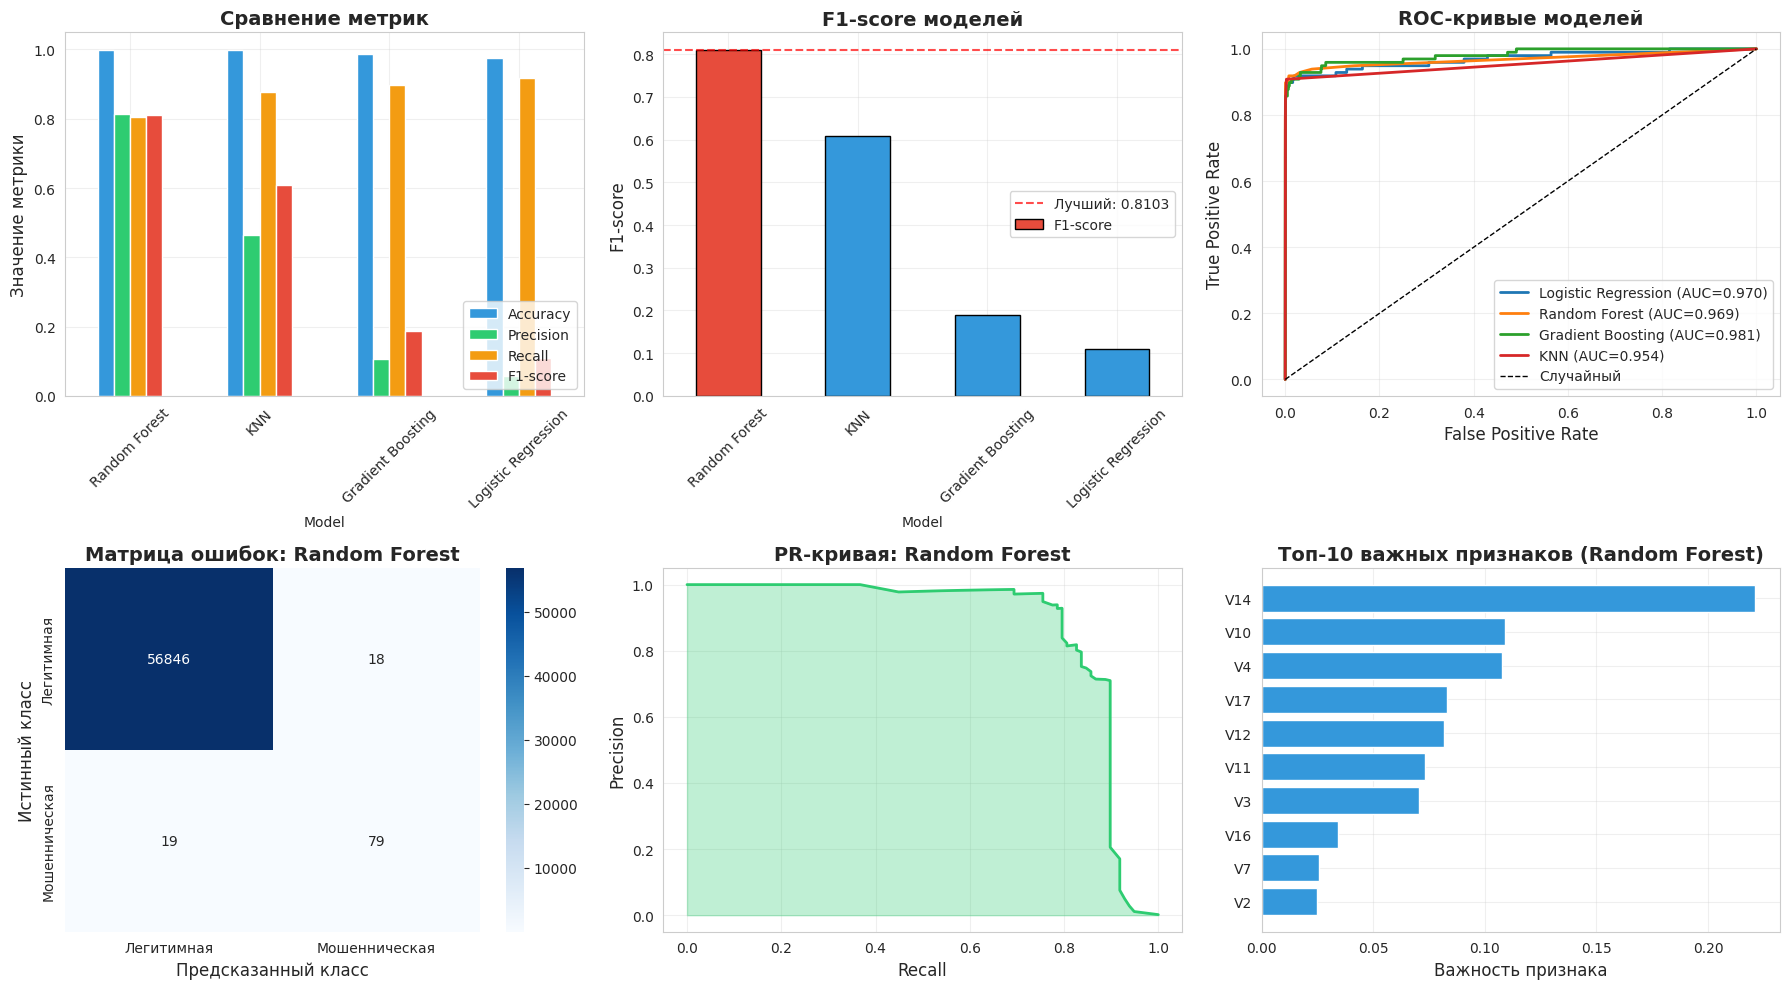

In [31]:
print("\n Визуализация результатов...")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# График 1: Сравнение метрик
results_df_sorted.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1-score']].plot(
    kind='bar', ax=axes[0], rot=45,
    color=['#3498db', '#2ecc71', '#f39c12', '#e74c3c']
)
axes[0].set_title('Сравнение метрик', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Значение метрики', fontsize=12)
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

# График 2: F1-score
colors = ['#e74c3c' if x == best_f1 else '#3498db' for x in results_df_sorted['F1-score']]
results_df_sorted.set_index('Model')['F1-score'].plot(
    kind='bar', ax=axes[1], color=colors, edgecolor='black', rot=45
)
axes[1].axhline(y=best_f1, color='red', linestyle='--', alpha=0.7,
                label=f'Лучший: {best_f1:.4f}')
axes[1].set_title('F1-score моделей', fontsize=14, fontweight='bold')
axes[1].set_ylabel('F1-score', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# График 3: ROC-AUC
ax_roc = axes[2]
for key in results.keys():
    if results[key]['y_pred_proba'] is not None:
        fpr, tpr, _ = roc_curve(y_test_final, results[key]['y_pred_proba'])
        auc = results[key]['roc_auc']
        ax_roc.plot(fpr, tpr, label=f'{model_names[key]} (AUC={auc:.3f})', linewidth=2)
ax_roc.plot([0, 1], [0, 1], 'k--', label='Случайный', linewidth=1)
ax_roc.set_xlabel('False Positive Rate', fontsize=12)
ax_roc.set_ylabel('True Positive Rate', fontsize=12)
ax_roc.set_title('ROC-кривые моделей', fontsize=14, fontweight='bold')
ax_roc.legend(loc='lower right', fontsize=10)
ax_roc.grid(True, alpha=0.3)

# График 4: Матрица ошибок для лучшей модели
best_model = results[best_key]['model']
y_pred_best = results[best_key]['y_pred']
cm = confusion_matrix(y_test_final, y_pred_best)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[3],
            xticklabels=['Легитимная', 'Мошенническая'],
            yticklabels=['Легитимная', 'Мошенническая'])
axes[3].set_title(f'Матрица ошибок: {best_model_name}', fontsize=14, fontweight='bold')
axes[3].set_xlabel('Предсказанный класс', fontsize=12)
axes[3].set_ylabel('Истинный класс', fontsize=12)

# График 5: Precision-Recall кривая
from sklearn.metrics import precision_recall_curve
if results[best_key]['y_pred_proba'] is not None:
    precision_vals, recall_vals, _ = precision_recall_curve(
        y_test_final, results[best_key]['y_pred_proba']
    )
    axes[4].plot(recall_vals, precision_vals, linewidth=2, color='#2ecc71')
    axes[4].fill_between(recall_vals, precision_vals, alpha=0.3, color='#2ecc71')
    axes[4].set_xlabel('Recall', fontsize=12)
    axes[4].set_ylabel('Precision', fontsize=12)
    axes[4].set_title(f'PR-кривая: {best_model_name}', fontsize=14, fontweight='bold')
    axes[4].grid(True, alpha=0.3)

# График 6: Важность признаков (для Random Forest)
if 'Random_Forest' in results:
    rf_model = results['Random_Forest']['model']
    if hasattr(rf_model, 'feature_importances_'):
        importances = rf_model.feature_importances_
        feature_names = X_test_final.columns

        # Берем топ-10 признаков
        indices = np.argsort(importances)[-10:]
        axes[5].barh(range(len(indices)), importances[indices], color='#3498db')
        axes[5].set_yticks(range(len(indices)))
        axes[5].set_yticklabels([feature_names[i] for i in indices])
        axes[5].set_xlabel('Важность признака', fontsize=12)
        axes[5].set_title('Топ-10 важных признаков (Random Forest)', fontsize=14, fontweight='bold')
        axes[5].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('model_evaluation_no_svm.png', dpi=300, bbox_inches='tight')
plt.show()

# Демонстрация работы модели на новых данных

Этот блок кода показывает, как обученная модель машинного обучения работает на практике. Он создает несколько разных примеров транзакций, делает предсказания и выводит результаты.

Находит транзакции в тестовой выборке. Блок берет из тестовой выборки индексы мошеннических и легитимных транзакций, чтобы использовать их для демонстрации.

Создает 5 типов транзакций:

Реальная легитимная – показывает, что модель не ошибается на обычных транзакциях

Реальная мошенническая – показывает, что модель находит явное мошенничество

Легитимная с шумом – проверяет устойчивость модели к небольшим изменениям

Мошенническая с шумом – проверяет, находит ли модель мошенничество даже с изменениями

Смешанная – показывает, как модель работает на пограничных случаях

Выполняет предсказания. Для каждой транзакции модель определяет класс (легитимная или мошенническая) и вычисляет вероятность мошенничества.

Определяет уровень риска. На основе вероятности присваивается уровень: высокий (более 70%), средний (30-70%) или низкий (менее 30%).

Выводит результаты. Для каждой транзакции показывает истинный класс, предсказанный класс, вероятность, уровень риска и совпадение с реальностью.

Подводит итоги. Считает точность на этих пяти примерах и выводит метрики модели.

In [56]:
# Подготовка данных для демонстрации
fraud_indices = np.where(y_test_final == 1)[0]
legit_indices = np.where(y_test_final == 0)[0]

test_cases = []
true_labels = []
case_descriptions = []

# Транзакция 1: реальная легитимная
if len(legit_indices) > 0:
    idx = legit_indices[0]
    test_cases.append(X_test_final.iloc[idx])
    true_labels.append(0)
    case_descriptions.append("Легитимная транзакция (реальная)")

# Транзакция 2: реальная мошенническая
if len(fraud_indices) > 0:
    idx = fraud_indices[0]
    test_cases.append(X_test_final.iloc[idx])
    true_labels.append(1)
    case_descriptions.append("Мошенническая транзакция (реальная)")

# Транзакция 3: легитимная с шумом
if len(legit_indices) > 1:
    idx = legit_indices[1]
    real_transaction = X_test_final.iloc[idx].copy()
    noise = np.random.normal(0, 0.15, len(real_transaction))
    new_transaction = real_transaction + noise * 0.5
    test_cases.append(new_transaction)
    true_labels.append(0)
    case_descriptions.append("Легитимная с небольшими изменениями")

# Транзакция 4: мошенническая с шумом
if len(fraud_indices) > 1:
    idx = fraud_indices[1]
    real_transaction = X_test_final.iloc[idx].copy()
    noise = np.random.normal(0, 0.15, len(real_transaction))
    new_transaction = real_transaction + noise * 0.5
    test_cases.append(new_transaction)
    true_labels.append(1)
    case_descriptions.append("Мошенническая с небольшими изменениями")

# Транзакция 5: смешанная
if len(legit_indices) > 2 and len(fraud_indices) > 2:
    legit_idx = legit_indices[2]
    fraud_idx = fraud_indices[2]

    legit_transaction = X_test_final.iloc[legit_idx].copy()
    fraud_transaction = X_test_final.iloc[fraud_idx].copy()

    mixed_transaction = 0.7 * legit_transaction + 0.3 * fraud_transaction
    test_cases.append(mixed_transaction)
    true_labels.append(1)
    case_descriptions.append("Смешанная (70% легитимная + 30% мошенническая)")

print(f"   Создано {len(test_cases)} транзакций")

# Выполнение предсказаний
print("\n2. Выполнение предсказаний...")

correct_predictions = 0

for i, (transaction, true_label, description) in enumerate(zip(test_cases, true_labels, case_descriptions), 1):
    X_sample = pd.DataFrame([transaction])

    y_pred = best_model.predict(X_sample)[0]
    y_proba = best_model.predict_proba(X_sample)[0][1]

    is_correct = (true_label == y_pred)
    if is_correct:
        correct_predictions += 1

    if y_proba > 0.7:
        risk = "Высокий"
    elif y_proba > 0.3:
        risk = "Средний"
    else:
        risk = "Низкий"

    true_class = "Мошенническая" if true_label == 1 else "Легитимная"
    pred_class = "Мошенническая" if y_pred == 1 else "Легитимная"
    result_text = "Совпадает" if is_correct else "Не совпадает"

    print(f"\nТранзакция {i}: {description}")
    print(f"   Истинный класс:     {true_class}")
    print(f"   Предсказанный класс: {pred_class}")
    print(f"   Вероятность:         {y_proba:.2%}")
    print(f"   Уровень риска:       {risk}")
    print(f"   Результат:           {result_text}")

# Итоговая статистика
accuracy = correct_predictions / len(test_cases) * 100

print(f"\nИтоговая статистика:")
print(f"   Всего транзакций:     {len(test_cases)}")
print(f"   Правильно предсказано: {correct_predictions}")
print(f"   Точность:              {accuracy:.1f}%")

# Информация о модели
print("\nИнформация о модели:")

if best_model_name in results:
    print(f"   Лучшая модель: {best_model_name}")
    print(f"   F1-score:      {results[best_model_name]['f1']:.4f}")
    print(f"   Precision:     {results[best_model_name]['precision']:.4f}")
    print(f"   Recall:        {results[best_model_name]['recall']:.4f}")
else:
    for key in results.keys():
        print(f"   Доступная модель: {key}")
        print(f"   F1-score:         {results[key]['f1']:.4f}")
        print(f"   Precision:        {results[key]['precision']:.4f}")
        print(f"   Recall:           {results[key]['recall']:.4f}")

print("\nДемонстрация завершена")

   Создано 5 транзакций

2. Выполнение предсказаний...

Транзакция 1: Легитимная транзакция (реальная)
   Истинный класс:     Легитимная
   Предсказанный класс: Легитимная
   Вероятность:         0.00%
   Уровень риска:       Низкий
   Результат:           Совпадает

Транзакция 2: Мошенническая транзакция (реальная)
   Истинный класс:     Мошенническая
   Предсказанный класс: Мошенническая
   Вероятность:         94.00%
   Уровень риска:       Высокий
   Результат:           Совпадает

Транзакция 3: Легитимная с небольшими изменениями
   Истинный класс:     Легитимная
   Предсказанный класс: Легитимная
   Вероятность:         0.00%
   Уровень риска:       Низкий
   Результат:           Совпадает

Транзакция 4: Мошенническая с небольшими изменениями
   Истинный класс:     Мошенническая
   Предсказанный класс: Мошенническая
   Вероятность:         95.00%
   Уровень риска:       Высокий
   Результат:           Совпадает

Транзакция 5: Смешанная (70% легитимная + 30% мошенническая)
   Исти

### Основные выводы:
1. Лучшая модель: Random Forest
   - F1-score: 0.8103
   - Это означает, что модель хорошо сбалансирована между точностью и полнотой


2. Дисбаланс классов - критическая проблема, требующая SMOTE

3. Выбор метрик - F1-score важнее accuracy

4. MLflow - незаменим для отслеживания экспериментов

5. Визуализация - помогает принимать решения

6. Воспроизводимость - seed фиксирует результаты